In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import FIGURES_DIR

from src.data.data_loader import load_unsupervised_features

from src.eda.eda_utils import get_dataframe_overview

from src.clustering.clustering_preprocessing import ClusteringPreprocessingBuilder
from src.clustering.clustering_models import ClusteringModelTrainer
from src.clustering.clustering_evaluation import ClusteringEvaluator
from src.clustering.cluster_seperation import NumericClusterSeperationAnalyzer

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

The scope of this notebook is to segment customers based on credit-risk profile and financial behavior features.

Unsupervised modeling workflow uses the processed features created during preprocessing and future engineering steps.

The clustering approaches compared in this notebook will be:
* KMeans as the baseline centroid-based model
* MiniBatchKMeans as a scalable centroid-based benchmark
* Gaussian Mixture Model as a probabilistic benchmark
* BisectingKMeans as a scalable hierarchical-style centroid benchmark

#### **Unsupervised Features**

In [2]:
### loading features
# unsupervised features
unsupervised_features = load_unsupervised_features()
print(f'Unsupervised features shape: {unsupervised_features.shape}')
unsupervised_features.head()

Unsupervised features shape: (59472, 43)


,Loan To Value,Branch ID,Age,Employment Type,State,FICO Score,Number of Accounts,Number of Active Accounts,Number of Overdue Accounts,Current Balance Amount,Disbursed Amount,Instalment Amount,Number of Accounts Opened Last 6 Months,Number of Delinquencies Last 6 Months,Average Account Age,Number of Inquiries,DisbursementYear,DisbursementQuarter,DisbursementMonth,DaysSinceDisbursement,IsBureauExcluded,Legit FICO Scores,FICO Rating,FICO Rating Ordinal,HasNegativeCurrentBalance,HasZeroCurrentBalance,CurrentBalancePositiveAmount,InstalmentToDisbursedRatio,BalanceToDisbursedRatio,HasNoActiveAccounts,ActiveAccountRatio,OverdueAccountRatio,RecentlyOpenedAccountRatio,RecentlyDelinquencyAccountRatio,CreditHistoryAgeBand,AccountsPerCreditHistoryMonth,RecentlyOpenedAccountsPerCreditHistoryMonth,InquiryIntensityBand,InquiryPerCreditHistoryMonth,InquiryToAccountRatio,IsHighLTV,IsVeryHighLTV,Legit LTV
0,73.23,67,33,Self employed,Nevada,598,1,1.0,1,27600,50200,1991,0,1,13,0,2018,3,9,56,0,598.0,Fair,2,0,0,27600,0.039661,0.549801,0,1.0,1.0,0.0,1.0,Established,0.076923,0.0,No Inquiry,0.000000,0.000000,0,0,73.23
1,88.48,67,25,Self employed,Nevada,305,3,0.0,0,0,0,31,0,0,8,1,2018,4,10,86,0,305.0,Poor,1,0,1,0,NaN,NaN,1,0.0,0.0,0.0,0.0,Young,0.375000,0.0,Single Inquiry,0.125000,0.333333,1,0,88.48
2,89.66,67,28,Self employed,Nevada,825,2,0.0,0,0,0,1347,0,0,21,0,2018,3,9,49,0,825.0,Exceptional,5,0,1,0,NaN,NaN,1,0.0,0.0,0.0,0.0,Established,0.095238,0.0,No Inquiry,0.000000,0.000000,1,0,89.66
3,71.89,67,29,Salaried,Nevada,17,1,1.0,0,72879,74500,0,0,0,2,0,2018,3,9,46,1,NaN,Bureau Excluded,0,0,0,72879,0.000000,0.978242,0,1.0,0.0,0.0,0.0,Very Young,0.500000,0.0,No Inquiry,0.000000,0.000000,0,0,71.89
4,89.56,67,27,Self employed,Nevada,718,1,1.0,0,-41,365384,0,0,0,56,1,2018,3,9,35,0,718.0,Good,3,1,0,0,0.000000,0.000000,0,1.0,0.0,0.0,0.0,Mature,0.017857,0.0,Single Inquiry,0.017857,1.000000,1,0,89.56


In [3]:
### unsupervised features - dataframe overview
overview = get_dataframe_overview(df = unsupervised_features)
overview

,dtype,missing_count,missing_rate,unique_count,unique_rate
InstalmentToDisbursedRatio,float64,11600,0.1950,29509,0.4962
BalanceToDisbursedRatio,float64,11120,0.1870,41082,0.6908
Legit FICO Scores,float64,6522,0.1097,561,0.0094
AccountsPerCreditHistoryMonth,float64,1809,0.0304,1114,0.0187
InquiryPerCreditHistoryMonth,float64,1809,0.0304,257,0.0043
RecentlyOpenedAccountsPerCreditHistoryMonth,float64,1809,0.0304,243,0.0041
ActiveAccountRatio,float64,222,0.0037,415,0.0070
Number of Active Accounts,float64,222,0.0037,36,0.0006
Legit LTV,float64,34,0.0006,5346,0.0899
Current Balance Amount,int64,0,0.0000,39065,0.6569


In [4]:
### unsupervised features - inspecting clustering feature groups
clustering_preprocessor = ClusteringPreprocessingBuilder(
    low_cardinality_threshold = 10,
    high_cardinality_categorical_features = ['State'],
    columns_to_exclude = ['Target']
)

# drop target variable if present in unsupervised features
X_clustering = clustering_preprocessor.clean_clustering_input(df = unsupervised_features)

# get feature groups
feature_groups = clustering_preprocessor.get_feature_groups(X = X_clustering)
feature_groups

{'numeric_features': ['Loan To Value',
  'Branch ID',
  'Age',
  'FICO Score',
  'Number of Accounts',
  'Number of Active Accounts',
  'Number of Overdue Accounts',
  'Current Balance Amount',
  'Disbursed Amount',
  'Instalment Amount',
  'Number of Accounts Opened Last 6 Months',
  'Number of Delinquencies Last 6 Months',
  'Average Account Age',
  'Number of Inquiries',
  'DisbursementYear',
  'DisbursementQuarter',
  'DisbursementMonth',
  'DaysSinceDisbursement',
  'IsBureauExcluded',
  'Legit FICO Scores',
  'FICO Rating Ordinal',
  'HasNegativeCurrentBalance',
  'HasZeroCurrentBalance',
  'CurrentBalancePositiveAmount',
  'InstalmentToDisbursedRatio',
  'BalanceToDisbursedRatio',
  'HasNoActiveAccounts',
  'ActiveAccountRatio',
  'OverdueAccountRatio',
  'RecentlyOpenedAccountRatio',
  'RecentlyDelinquencyAccountRatio',
  'AccountsPerCreditHistoryMonth',
  'RecentlyOpenedAccountsPerCreditHistoryMonth',
  'InquiryPerCreditHistoryMonth',
  'InquiryToAccountRatio',
  'IsHighLTV',


In [5]:
# diagnostics
X_clustering = clustering_preprocessor.clean_clustering_input(
    df=unsupervised_features
)

numeric_features = X_clustering.select_dtypes(
    include=["number", "bool"]
)

quantile_summary = numeric_features.quantile(
    [0.00, 0.01, 0.25, 0.50, 0.75, 0.99, 1.00]
).T

quantile_summary["iqr"] = (
    quantile_summary[0.75] - quantile_summary[0.25]
)

quantile_summary["range"] = (
    quantile_summary[1.00] - quantile_summary[0.00]
)

quantile_summary["range_to_iqr_ratio"] = (
    quantile_summary["range"] / quantile_summary["iqr"].replace(0, np.nan)
)

suspicious_features = (
    quantile_summary
    .sort_values("range_to_iqr_ratio", ascending=False)
    .head(20)
)

suspicious_features

,0.0,0.01,0.25,0.5,0.75,0.99,1.0,iqr,range,range_to_iqr_ratio
BalanceToDisbursedRatio,0.000000e+00,0.000000,0.391608,0.680857,0.901113,1.346178e+00,5.758200e+04,0.509505,5.758200e+04,113015.621143
Disbursed Amount,0.000000e+00,0.000000,12500.000000,57800.000000,285909.250000,4.950454e+06,1.000000e+09,273409.250000,1.000000e+09,3657.520731
Loan To Value,1.558000e+01,40.327100,69.770000,77.970000,84.490000,8.998000e+01,4.638600e+04,14.720000,4.637042e+04,3150.164402
Instalment Amount,0.000000e+00,0.000000,0.000000,1933.000000,7803.500000,3.496255e+05,2.076655e+07,7803.500000,2.076655e+07,2661.184469
InstalmentToDisbursedRatio,0.000000e+00,0.000000,0.000000,0.019846,0.087269,1.840791e+00,1.629574e+02,0.087269,1.629574e+02,1867.305771
Current Balance Amount,-6.678296e+06,0.000000,2000.000000,31874.000000,181127.250000,4.211843e+06,9.652492e+07,179127.250000,1.032032e+08,576.144702
CurrentBalancePositiveAmount,0.000000e+00,0.000000,2000.000000,31874.000000,181127.250000,4.211843e+06,9.652492e+07,179127.250000,9.652492e+07,538.862289
AccountsPerCreditHistoryMonth,8.547009e-03,0.015385,0.117647,0.285714,0.750000,1.500000e+01,2.265000e+02,0.632353,2.264915e+02,358.172530
RecentlyOpenedAccountsPerCreditHistoryMonth,0.000000e+00,0.000000,0.000000,0.000000,0.166667,3.000000e+00,2.000000e+01,0.166667,2.000000e+01,120.000000
Number of Accounts,1.000000e+00,1.000000,1.000000,3.000000,6.000000,2.800000e+01,4.530000e+02,5.000000,4.520000e+02,90.400000


#### **Modeling**

The clustering workflow follows the same modular design as the supervised modeling workflow.

Processing pipeline steps:
* numeric imputation
* robust scaling
* one-hot encoding for low-cardinality categorical features
* frequency-encoding for high-cardinality categorical features

The clustering models are compared across different cluster numbers using internal validation metrics:
* Silhouette score: higher is better
* Calinski-Harabasz score: higher is better
* Davies-Bouldin score: lower is better
* Inertia: lower is better

In [6]:
### unsupervised model - initialize trainer
clustering_trainer = ClusteringModelTrainer(
    cluster_range = range(3, 7),
    random_state = 2,
    preprocessing_builder = clustering_preprocessor,
    evaluator = ClusteringEvaluator(
        silhouette_sample_size = 10_000,
        random_state = 2
    ),
    algorithms = [
        'kmeans',
        'minibatch_kmeans',
        'gaussian_mixture',
        'bisecting_kmeans'
    ]
)

# candidate clustering models for a sample n_clusters
sample_n_clusters = 3
candidate_clusterers = clustering_trainer.get_candidate_clusterers(n_clusters = sample_n_clusters)
candidate_clusterers

{'kmeans_k3': KMeans(n_clusters=3, random_state=2),
 'minibatch_kmeans_k3': MiniBatchKMeans(max_iter=300, n_clusters=3, random_state=2),
 'gaussian_mixture_k3': GaussianMixture(covariance_type='diag', max_iter=300, n_components=3, n_init=3,
                 random_state=2),
 'bisecting_kmeans_k3': BisectingKMeans(max_iter=150, n_clusters=3, random_state=2)}

In [7]:
### unsupervised model - train candidate clustering models using the clustering pipeline
clustering_metrics = clustering_trainer.train_all_models(
    save_models = True,
    save_metrics = True,
    save_cluster_labels = True
)
clustering_metrics

Training kmeans_k3
Training minibatch_kmeans_k3
Training gaussian_mixture_k3
Training bisecting_kmeans_k3
Training kmeans_k4
Training minibatch_kmeans_k4
Training gaussian_mixture_k4
Training bisecting_kmeans_k4
Training kmeans_k5
Training minibatch_kmeans_k5
Training gaussian_mixture_k5
Training bisecting_kmeans_k5
Training kmeans_k6
Training minibatch_kmeans_k6
Training gaussian_mixture_k6
Training bisecting_kmeans_k6


,model,n_clusters,n_observations,n_assigned_clusters,inertia,davies_bouldin_score,calinski_harabasz_score,silhouette_score,is_valid_clustering,evaluation_note,cluster_sizes,min_cluster_count,min_cluster_share,n_iter,gmm_lower_bound
0,kmeans_k6,6,59472,6,2.353860e+06,0.939952,23334.512809,0.440757,True,Valid clustering solution,"{0: 2938, 1: 47922, 2: 1454, 3: 4906, 4: 998, 5: 1254}",998,0.016781,34.0,NaN
1,kmeans_k5,5,59472,5,2.651026e+06,0.930774,24232.495695,0.429965,True,Valid clustering solution,"{0: 2996, 1: 48711, 2: 1459, 3: 4990, 4: 1316}",1316,0.022128,42.0,NaN
2,bisecting_kmeans_k5,5,59472,5,2.724060e+06,1.033954,23184.219070,0.350330,True,Valid clustering solution,"{0: 2197, 1: 1409, 2: 47254, 3: 5392, 4: 3220}",1409,0.023692,NaN,NaN
3,minibatch_kmeans_k5,5,59472,5,2.719781e+06,1.160987,23535.725175,0.283721,True,Valid clustering solution,"{0: 8699, 1: 2340, 2: 1286, 3: 44309, 4: 2838}",1286,0.021624,1.0,NaN
4,bisecting_kmeans_k6,6,59472,6,2.555813e+06,1.434523,20550.927266,0.251398,True,Valid clustering solution,"{0: 2197, 1: 1409, 2: 38076, 3: 9178, 4: 5392, 5: 3220}",1409,0.023692,NaN,NaN
5,minibatch_kmeans_k6,6,59472,6,2.508363e+06,1.456266,21318.046447,0.199924,True,Valid clustering solution,"{0: 6717, 1: 2032, 2: 1288, 3: 15725, 4: 2563, 5: 31147}",1288,0.021657,2.0,NaN
6,minibatch_kmeans_k4,4,59472,4,3.469996e+06,1.711845,20050.045974,0.095402,True,Valid clustering solution,"{0: 17813, 1: 2718, 2: 1320, 3: 37621}",1320,0.022195,1.0,NaN
7,gaussian_mixture_k3,3,59472,3,NaN,4.375959,2080.784456,-0.019812,True,Valid clustering solution,"{0: 8261, 1: 20047, 2: 31164}",8261,0.138906,37.0,11.479355
8,gaussian_mixture_k5,5,59472,5,NaN,2.939416,2732.217078,-0.075365,True,Valid clustering solution,"{0: 11272, 1: 11465, 2: 4903, 3: 27438, 4: 4394}",4394,0.073884,17.0,20.850639
9,gaussian_mixture_k6,6,59472,6,NaN,3.612586,2337.358842,-0.078093,True,Valid clustering solution,"{0: 9837, 1: 6139, 2: 2228, 3: 23616, 4: 13455, 5: 4197}",2228,0.037463,33.0,43.592175


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Silhouette Score by Model and Cluster Count - higher is better'}, xlabel='Number of Clusters', ylabel='Silhouette score'>)

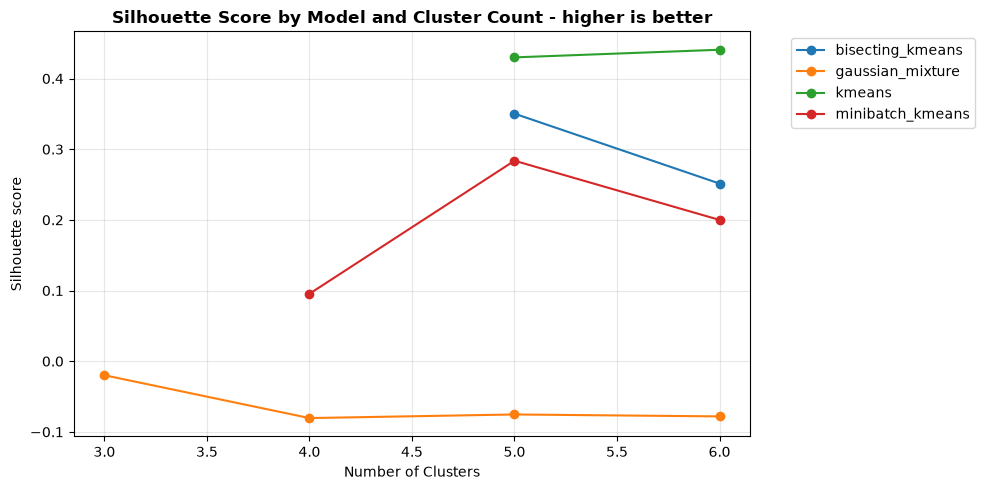

In [8]:
### unsupervised model - plotting clustering metrics - Silhouette Score
clustering_trainer.evaluator.plot_silhouette_score(
    metrics_df = clustering_metrics,
    require_valid = True,
    save_path = FIGURES_DIR / 'clustering_silhouette_score.png'
)

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Davies-Bouldin Score by Model and Cluster Count - lower is better'}, xlabel='Number of Clusters', ylabel='Davies-Bouldin score'>)

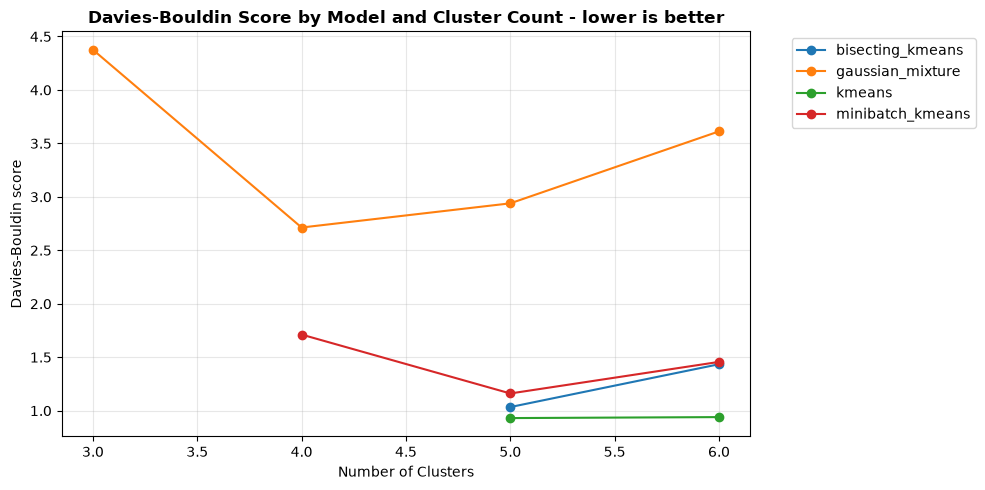

In [9]:
### unsupervised model - plotting clustering metrics - Davies-Bouldin Score
clustering_trainer.evaluator.plot_davies_bouldin_score(
    metrics_df = clustering_metrics,
    require_valid = True,
    save_path = FIGURES_DIR / 'clustering_davies_bouldin_score.png'
)

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Calinski-Harabasz Score by Model and Cluster Count - higher is better'}, xlabel='Number of Clusters', ylabel='Calinski-Harabasz score'>)

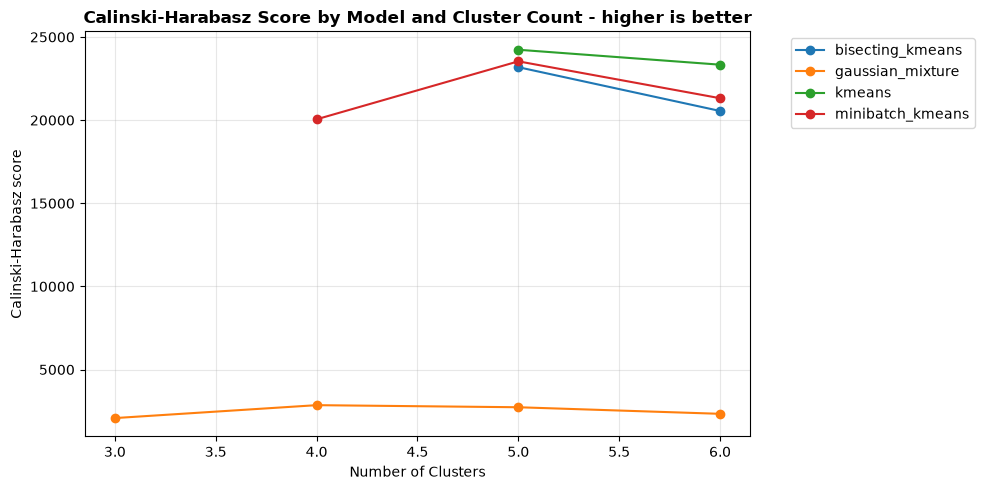

In [10]:
### unsupervised model - plotting clustering metrics - Calinski-Harabasz Score
clustering_trainer.evaluator.plot_calinski_harabasz_score(
    metrics_df = clustering_metrics,
    require_valid = True,
    save_path = FIGURES_DIR / 'clustering_calinski_harabasz_score.png'
)

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'KMeans Inertia Elbow Plot (lower is better)'}, xlabel='Number of clusters', ylabel='Inertia'>)

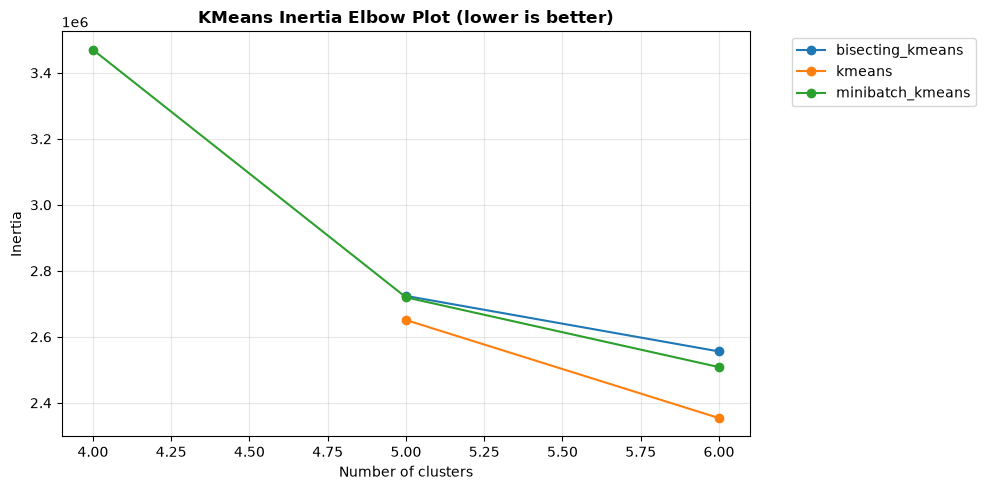

In [11]:
### unsupervised model - plotting clustering metrics - KMeans Inertia Elbow
clustering_trainer.evaluator.plot_kmeans_inertia_elbow(
    metrics_df = clustering_metrics,
    require_valid = True,
    save_path = FIGURES_DIR / 'clustering_kmeans_inertia_elbow.png'
)

In [12]:
### unsupervised model - comparing cluster size summary - promising top 3 clustering models 
promising_cluster_models = (
    clustering_metrics['model']
    .head(3)
    .tolist()
)

cluster_labels = clustering_trainer.cluster_labels_

if cluster_labels is None:
    raise ValueError("cluster_labels_ is not available, please train the clustering models first!")

for model_name in promising_cluster_models:  

    if model_name not in cluster_labels:
        raise KeyError(f'{model_name} not found in cluster_labels_')

    labels = cluster_labels[model_name]
    
    if not isinstance(labels, pd.Series):
        labels = pd.Series(
            labels,
            name = 'cluster_label'
        )
    
    cluster_size_summary = (
        labels
        .value_counts()
        .sort_index()
        .to_frame(name = 'customer_count')
        .assign(
            customer_share = lambda x: x['customer_count'] / x['customer_count'].sum()
        )
    )

    cluster_size_summary['customer_share'] = cluster_size_summary['customer_share'].round(4)

    display(cluster_size_summary)

,customer_count,customer_share
kmeans_k6,,
0,2938,0.0494
1,47922,0.8058
2,1454,0.0244
3,4906,0.0825
4,998,0.0168
5,1254,0.0211


,customer_count,customer_share
kmeans_k5,,
0,2996,0.0504
1,48711,0.8191
2,1459,0.0245
3,4990,0.0839
4,1316,0.0221


,customer_count,customer_share
bisecting_kmeans_k5,,
0,2197,0.0369
1,1409,0.0237
2,47254,0.7946
3,5392,0.0907
4,3220,0.0541


#### **Cluster Seperation**

To identify which variables best explain the cluster structure, numeric cluster-seperation importance is calculated with respect to:
* eta-squared: share of feature variance explained by cluster membership
* ANOVA F-score: statistical seperation of feature values across clusters
* standardized cluster mean spread: largest standardized deviation between a cluster mean and the portfolio average

The cluster seperation analysis is used to support the selection of features for cluster profiling

In [13]:
### unsupervised model - comparing numeric cluster-seperation importance summary - promising top 3 clustering models 
# initialize cluster seperation analyzer
cluster_seperation_analyzer = NumericClusterSeperationAnalyzer()
# numeric cluster-seperation importances
cluster_labels = clustering_trainer.cluster_labels_

if cluster_labels is None:
    raise ValueError("cluster_labels_ is not available, please train the clustering models first!")

numeric_cluster_seperation = cluster_seperation_analyzer.analyze_multiple_models(
    df = unsupervised_features,
    cluster_labels = cluster_labels,
    model_names = promising_cluster_models,
    exclude_columns = ['Target']
)

# get top features per promising clustering model
top_n = 10
for model_name in promising_cluster_models:
    print(f'Top {top_n} numeric cluster-seperation features - {model_name}')
    print()
    display(
        cluster_seperation_analyzer
        .get_top_features(
            seperation_df = numeric_cluster_seperation,
            top_n = top_n,
            model_name = model_name
        )
    )

Top 10 numeric cluster-seperation features - kmeans_k6



,model,feature,eta_squared,cluster_mean_min,cluster_mean_max,cluster_mean_range,cluster_with_min_mean,cluster_with_max_mean,max_abs_standardized_cluster_mean,anova_f_score,anova_p_value
0,kmeans_k6,AccountsPerCreditHistoryMonth,0.452157,0.494986,9.714251e+00,9.219265e+00,1,0,2.902806,9815.925547,0.0
1,kmeans_k6,RecentlyOpenedAccountsPerCreditHistoryMonth,0.424075,0.116763,1.790722e+00,1.673960e+00,1,0,2.840581,8757.408226,0.0
2,kmeans_k6,CurrentBalancePositiveAmount,0.370758,75962.848984,4.910674e+06,4.834711e+06,1,2,3.442547,7007.644856,0.0
3,kmeans_k6,Current Balance Amount,0.370323,75912.598806,4.910674e+06,4.834761e+06,1,2,3.441749,6994.589690,0.0
4,kmeans_k6,Instalment Amount,0.228441,3985.145695,7.217250e+05,7.177398e+05,1,4,3.617958,3521.296323,0.0
5,kmeans_k6,Number of Active Accounts,0.211945,1.578565,5.958735e+00,4.380169e+00,1,2,1.756476,3198.642769,0.0
6,kmeans_k6,Number of Accounts,0.181212,3.559138,1.416433e+01,1.060519e+01,1,4,1.498602,2632.165188,0.0
7,kmeans_k6,InquiryPerCreditHistoryMonth,0.119718,0.032593,7.900055e-01,7.574120e-01,3,0,1.515572,1617.465136,0.0
8,kmeans_k6,Number of Accounts Opened Last 6 Months,0.105540,0.599829,2.270933e+00,1.671104e+00,1,0,1.252113,1403.321382,0.0
9,kmeans_k6,InstalmentToDisbursedRatio,0.095202,0.009741,2.318210e+00,2.308468e+00,2,4,1.966670,1251.388451,0.0


Top 10 numeric cluster-seperation features - kmeans_k5



,model,feature,eta_squared,cluster_mean_min,cluster_mean_max,cluster_mean_range,cluster_with_min_mean,cluster_with_max_mean,max_abs_standardized_cluster_mean,anova_f_score,anova_p_value
0,kmeans_k5,AccountsPerCreditHistoryMonth,0.454564,0.496261,9.667302e+00,9.171041e+00,1,0,2.887106,12389.900452,0.0
1,kmeans_k5,RecentlyOpenedAccountsPerCreditHistoryMonth,0.420888,0.116546,1.769551e+00,1.653005e+00,1,0,2.802592,10804.898202,0.0
2,kmeans_k5,CurrentBalancePositiveAmount,0.366911,75218.196321,4.914700e+06,4.839482e+06,1,2,3.445567,8616.131022,0.0
3,kmeans_k5,Current Balance Amount,0.366548,75168.437129,4.914700e+06,4.839531e+06,1,2,3.444768,8602.661728,0.0
4,kmeans_k5,Number of Active Accounts,0.208911,1.579499,5.960932e+00,4.381433e+00,1,2,1.757459,3926.004378,0.0
5,kmeans_k5,Instalment Amount,0.193831,4881.739155,5.853659e+05,5.804842e+05,1,4,2.914506,3574.485532,0.0
6,kmeans_k5,Number of Accounts,0.176885,3.583913,1.250152e+01,8.917606e+00,1,4,1.234372,3194.828803,0.0
7,kmeans_k5,InquiryPerCreditHistoryMonth,0.118478,0.032763,7.793512e-01,7.465886e-01,3,0,1.492355,1998.116009,0.0
8,kmeans_k5,Number of Accounts Opened Last 6 Months,0.103522,0.600357,2.243658e+00,1.643301e+00,1,0,1.229664,1716.751024,0.0
9,kmeans_k5,InstalmentToDisbursedRatio,0.085255,0.009854,2.285161e+00,2.275307e+00,2,4,1.937179,1385.587959,0.0


Top 10 numeric cluster-seperation features - bisecting_kmeans_k5



,model,feature,eta_squared,cluster_mean_min,cluster_mean_max,cluster_mean_range,cluster_with_min_mean,cluster_with_max_mean,max_abs_standardized_cluster_mean,anova_f_score,anova_p_value
0,bisecting_kmeans_k5,AccountsPerCreditHistoryMonth,0.424275,0.480106,9.016905e+00,8.536799e+00,2,4,2.669603,10955.930763,0.0
1,bisecting_kmeans_k5,RecentlyOpenedAccountsPerCreditHistoryMonth,0.409469,0.101036,1.685937e+00,1.584901e+00,3,4,2.652556,10308.480502,0.0
2,bisecting_kmeans_k5,CurrentBalancePositiveAmount,0.329593,62997.775045,3.908846e+06,3.845849e+06,2,0,2.691164,7308.970523,0.0
3,bisecting_kmeans_k5,Current Balance Amount,0.329255,62946.481610,3.908846e+06,3.845900e+06,2,0,2.690575,7297.780444,0.0
4,bisecting_kmeans_k5,Number of Active Accounts,0.221921,1.530304,5.563496e+00,4.033191e+00,2,0,1.579513,4240.238796,0.0
5,bisecting_kmeans_k5,Instalment Amount,0.187552,4683.747429,5.569040e+05,5.522203e+05,2,1,2.767677,3431.954471,0.0
6,bisecting_kmeans_k5,Number of Accounts,0.178119,3.505756,1.263946e+01,9.133704e+00,2,1,1.256291,3221.949310,0.0
7,bisecting_kmeans_k5,InquiryPerCreditHistoryMonth,0.120370,0.028026,7.588417e-01,7.308153e-01,3,4,1.447662,2034.383754,0.0
8,bisecting_kmeans_k5,Number of Accounts Opened Last 6 Months,0.107125,0.588077,2.195031e+00,1.606954e+00,2,4,1.189641,1783.680791,0.0
9,bisecting_kmeans_k5,InstalmentToDisbursedRatio,0.077707,0.013654,2.114778e+00,2.101124e+00,3,1,1.785142,1252.582641,0.0


In [14]:
### unsupervised model - most promising model - comparing numeric cluster-seperation importance summary 
selected_clustering_model_name = promising_cluster_models[0]
print(f'Most promising clustering model -> {selected_clustering_model_name.upper()}')

# domain-driven features
domain_driven_features = [
    'Age', 'Loan To Value', 'Legit LTV', 'FICO Score', 'Legit FICO Scores', 'Current Balance Amount', 'CurrentBalancePositiveAmount',
    'Disbursed Amount', 'Instalment Amount', 'BalanceToDisbursedRatio', 'InstalmentToDisbursedRatio', 'Number of Accounts',
    'Number of Active Accounts', 'Number of Overdue Accounts', 'Number of Accounts Opened Last 6 Months', 'Number of Delinquencies Last 6 Months',
    'Number of Inquiries', 'Average Account Age', 'AccountsPerCreditHistoryMonth', 'RecentlyOpenedAccountsPerCreditHistoryMonth', 'RecentlyOpenedAccountRatio'
]

# check if domain-driven features are not found the unsupervised dataset
cols_missing = [
    col
    for col in domain_driven_features
    if col not in unsupervised_features.columns
]

if cols_missing:
    raise ValueError(
        f'A subset of domain-driven features are not found in unsupervised_features dataframe!, '
        f'missing_columns={cols_missing}'
    )

# important profile features by combaning domain-driven and data-driven profile features for cluster profiling
important_profile_features = (
    cluster_seperation_analyzer
    .select_profile_features(
        seperation_df = numeric_cluster_seperation,
        domain_features = domain_driven_features,
        top_n_data_driven = top_n,
        model_name = selected_clustering_model_name
    )
)
important_profile_features

Most promising clustering model -> KMEANS_K6


['Age',
 'Loan To Value',
 'Legit LTV',
 'FICO Score',
 'Legit FICO Scores',
 'Current Balance Amount',
 'CurrentBalancePositiveAmount',
 'Disbursed Amount',
 'Instalment Amount',
 'BalanceToDisbursedRatio',
 'InstalmentToDisbursedRatio',
 'Number of Accounts',
 'Number of Active Accounts',
 'Number of Overdue Accounts',
 'Number of Accounts Opened Last 6 Months',
 'Number of Delinquencies Last 6 Months',
 'Number of Inquiries',
 'Average Account Age',
 'AccountsPerCreditHistoryMonth',
 'RecentlyOpenedAccountsPerCreditHistoryMonth',
 'RecentlyOpenedAccountRatio',
 'InquiryPerCreditHistoryMonth']

* these cluster profile features are selected based on credit-risk domain judgement and empirical cluster-seperation strength

In [15]:
### unsupervised model - most promising model - cluster profiling
profile_df = unsupervised_features.copy()

cluster_labels = clustering_trainer.cluster_labels_

if cluster_labels is None:
    raise ValueError("cluster_labels_ is not available, please train the clustering models first!")

# assign cluster labels of selected clustering model to the unsupervised features dataset 
profile_df['cluster'] = cluster_labels[selected_clustering_model_name].values

# cluster profile
cluster_numeric_profile = (
    profile_df
    .groupby('cluster')[important_profile_features]
    .mean()
    .round(3)
)
print('--- Cluster numeric profile ---')
print()
display(cluster_numeric_profile)

# relative cluster profile
global_average = profile_df[important_profile_features].mean()

cluster_relative_profile = (
    cluster_numeric_profile
    .divide(global_average)
    .round(2)
)

print('--- Cluster relative profile ---')
print()
display(cluster_relative_profile)

--- Cluster numeric profile ---



,Age,Loan To Value,Legit LTV,FICO Score,Legit FICO Scores,Current Balance Amount,CurrentBalancePositiveAmount,Disbursed Amount,Instalment Amount,BalanceToDisbursedRatio,InstalmentToDisbursedRatio,Number of Accounts,Number of Active Accounts,Number of Overdue Accounts,Number of Accounts Opened Last 6 Months,Number of Delinquencies Last 6 Months,Number of Inquiries,Average Account Age,AccountsPerCreditHistoryMonth,RecentlyOpenedAccountsPerCreditHistoryMonth,RecentlyOpenedAccountRatio,InquiryPerCreditHistoryMonth
cluster,,,,,,,,,,,,,,,,,,,,,,
0,35.124,93.198,77.520,607.269,661.828,199679.020,199692.272,265881.166,12159.820,0.663,0.099,12.159,3.964,0.249,2.271,0.226,0.892,1.377,9.714,1.791,0.300,0.790
1,35.390,106.286,75.496,583.763,664.759,75912.599,75962.849,121434.762,3985.146,2.912,0.059,3.559,1.581,0.252,0.600,0.144,0.325,16.065,0.503,0.121,0.213,0.064
2,38.918,77.097,77.097,577.679,590.745,4910673.618,4910673.618,5781650.611,48080.585,1.626,0.010,11.822,5.976,0.968,1.422,0.717,0.283,21.330,1.278,0.232,0.151,0.047
3,39.035,75.759,75.759,598.954,616.856,1219694.743,1219694.743,1706054.044,18213.113,0.863,0.014,7.384,3.727,0.555,0.966,0.384,0.255,20.865,0.612,0.121,0.164,0.033
4,40.699,75.096,75.096,569.473,584.861,1587165.260,1597189.095,2042395.235,721724.959,0.818,2.494,14.164,4.432,0.757,1.458,0.497,0.221,14.692,3.095,0.386,0.129,0.046
5,37.727,110.932,74.123,574.925,615.056,101291.224,101303.769,136591.405,85761.116,0.916,1.416,6.124,1.965,0.368,0.720,0.218,0.226,14.380,1.053,0.151,0.178,0.049


--- Cluster relative profile ---



,Age,Loan To Value,Legit LTV,FICO Score,Legit FICO Scores,Current Balance Amount,CurrentBalancePositiveAmount,Disbursed Amount,Instalment Amount,BalanceToDisbursedRatio,InstalmentToDisbursedRatio,Number of Accounts,Number of Active Accounts,Number of Overdue Accounts,Number of Accounts Opened Last 6 Months,Number of Delinquencies Last 6 Months,Number of Inquiries,Average Account Age,AccountsPerCreditHistoryMonth,RecentlyOpenedAccountsPerCreditHistoryMonth,RecentlyOpenedAccountRatio,InquiryPerCreditHistoryMonth
cluster,,,,,,,,,,,,,,,,,,,,,,
0,0.98,0.91,1.03,1.04,1.01,0.62,0.62,0.62,0.60,0.27,0.72,2.57,1.94,0.82,3.03,1.19,2.61,0.09,9.19,8.36,1.43,8.10
1,0.99,1.04,1.00,1.00,1.01,0.24,0.24,0.28,0.20,1.19,0.43,0.75,0.78,0.83,0.80,0.76,0.95,1.02,0.48,0.56,1.02,0.66
2,1.08,0.76,1.02,0.99,0.90,15.32,15.31,13.44,2.36,0.67,0.07,2.50,2.93,3.17,1.90,3.79,0.83,1.35,1.21,1.08,0.72,0.48
3,1.09,0.74,1.00,1.02,0.94,3.81,3.80,3.97,0.89,0.35,0.10,1.56,1.83,1.82,1.29,2.03,0.74,1.32,0.58,0.56,0.78,0.34
4,1.13,0.74,0.99,0.97,0.89,4.95,4.98,4.75,35.36,0.33,18.19,2.99,2.17,2.48,1.94,2.62,0.65,0.93,2.93,1.80,0.62,0.47
5,1.05,1.09,0.98,0.98,0.94,0.32,0.32,0.32,4.20,0.38,10.33,1.29,0.96,1.21,0.96,1.15,0.66,0.91,1.00,0.70,0.85,0.50
